In [1]:
import pandas as pd
import plotnine as p9

In [2]:
import numpy as np
import scanpy as sc

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mplpatches

In [4]:
p9.options.dpi=300
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'

In [8]:
OAK_multiome_RNA_FA_read=pd.read_csv(data_dir+'barnyard_OAKmultiomeRNA/reads_per_barcode',sep='\t', skipinitialspace = True,header=None)

In [9]:
OAK_multiome_RNA_FA_read=OAK_multiome_RNA_FA_read[0].str.split(pat=" ",expand=True)

In [10]:
OAK_multiome_RNA_FA_read.columns=['Read_count','cell_bc']

In [11]:
OAK_multiome_RNA_ME_read=pd.read_csv(data_dir+'barnyard_OAKmultiomeRNA_MeOH/reads_per_barcode',sep='\t', skipinitialspace = True,header=None)

In [12]:
OAK_multiome_RNA_ME_read=OAK_multiome_RNA_ME_read[0].str.split(pat=" ",expand=True)

In [13]:
OAK_multiome_RNA_ME_read.columns=['Read_count','cell_bc']

In [14]:
FA_adata = sc.read_10x_mtx(OAK_multiomeRNA_directoryname+'/FAWash2/outs/filtered_feature_bc_matrix',  
    var_names='gene_symbols',                  
    cache=True,gex_only=False)                                

In [15]:
FA_adata.obs['cell_bc']=FA_adata.obs.index.str.replace(r'-1','')

In [16]:
FA_adata.obs=FA_adata.obs.reset_index().merge(OAK_multiome_RNA_FA_read,how="left",left_on=["cell_bc"],right_on=["cell_bc"]).set_index('index')

In [17]:
FA_gem_classification=pd.read_csv(OAK_multiomeRNA_directoryname+'/FAWash2/outs/analysis/gem_classification.csv',header=0)

In [18]:
FA_adata.obs=FA_adata.obs.reset_index().merge(FA_gem_classification,how="left",left_on=['index'],right_on=["barcode"]).set_index('index')

In [19]:
FA_adata.obs['Read_count']=FA_adata.obs['Read_count'].astype(int)

In [20]:
class_dict={"Multiplet":'Multiplet_obs'} 
FA_adata.obs.replace({"call":class_dict},inplace=True) 

In [21]:
FA_adata.var[['species','gene_id']]=FA_adata.var.gene_ids.str.replace('___','_').str.split("_",expand=True)

In [22]:
FA_adata_K562=FA_adata[FA_adata.obs.call=='GRCh38',FA_adata.var.species=='GRCh38']

In [23]:
sc.pp.calculate_qc_metrics(FA_adata_K562, inplace=True)


/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/numba/core/dispatcher.py:289: UserWarning: Numba extension module 'sparse._numba_extension' failed to load due to 'ModuleNotFoundError(No module named 'numba.targets')'.
Trying to set attribute `.obs` of view, copying.


In [24]:
ME_adata = sc.read_10x_mtx(OAK_multiomeRNA_directoryname+'/MethWash2/outs/filtered_feature_bc_matrix',  
    var_names='gene_symbols',                  
    cache=True,gex_only=False)                                

In [25]:
ME_adata.obs['cell_bc']=ME_adata.obs.index.str.replace(r'-1','')

In [26]:
ME_adata.obs=ME_adata.obs.reset_index().merge(OAK_multiome_RNA_ME_read,how="left",left_on=["cell_bc"],right_on=["cell_bc"]).set_index('index')

In [27]:
ME_gem_classification=pd.read_csv(OAK_multiomeRNA_directoryname+'/MethWash2/outs/analysis/gem_classification.csv',header=0)

In [28]:
ME_adata.obs=ME_adata.obs.reset_index().merge(ME_gem_classification,how="left",left_on=['index'],right_on=["barcode"]).set_index('index')

In [29]:
ME_adata.obs['Read_count']=ME_adata.obs['Read_count'].astype(int)

In [30]:
ME_adata.obs.replace({"call":class_dict},inplace=True) 

In [31]:
ME_adata.var[['species','gene_id']]=ME_adata.var.gene_ids.str.replace('___','_').str.split("_",expand=True)

In [32]:
ME_adata_K562=ME_adata[ME_adata.obs.call=='GRCh38',ME_adata.var.species=='GRCh38']

In [33]:
sc.pp.calculate_qc_metrics(ME_adata_K562, inplace=True)


Trying to set attribute `.obs` of view, copying.


In [34]:
FA_adata_K562.obs['experiment']='OAK_FA'

In [35]:
df_OAK_FA_K562=FA_adata_K562.obs[['barcode','Read_count','n_genes_by_counts','total_counts','experiment']] 

In [36]:
ME_adata_K562.obs['experiment']='OAK_MeOH'

In [37]:
df_OAK_ME_K562=ME_adata_K562.obs[['barcode','Read_count','n_genes_by_counts','total_counts','experiment']] 

In [38]:
Control_multiome_RNA_K562=pd.read_csv(Control10x_multiome_RNA_directoryname+'/outs/per_barcode_metrics.csv',header=0)  

In [39]:
Control_multiome_RNA_K562_cells=Control_multiome_RNA_K562[Control_multiome_RNA_K562['is_cell']>0] 

In [40]:
df_control_K562=Control_multiome_RNA_K562_cells[['barcode','gex_raw_reads','gex_genes_count','gex_umis_count']]

In [41]:
df_control_K562['experiment']='Chromium'

/local/50469756/ipykernel_4246/2339810558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [42]:
df_control_K562.columns=df_OAK_ME_K562.columns

In [43]:
df_compare=pd.concat([df_control_K562,df_OAK_FA_K562,df_OAK_ME_K562],ignore_index=True)  

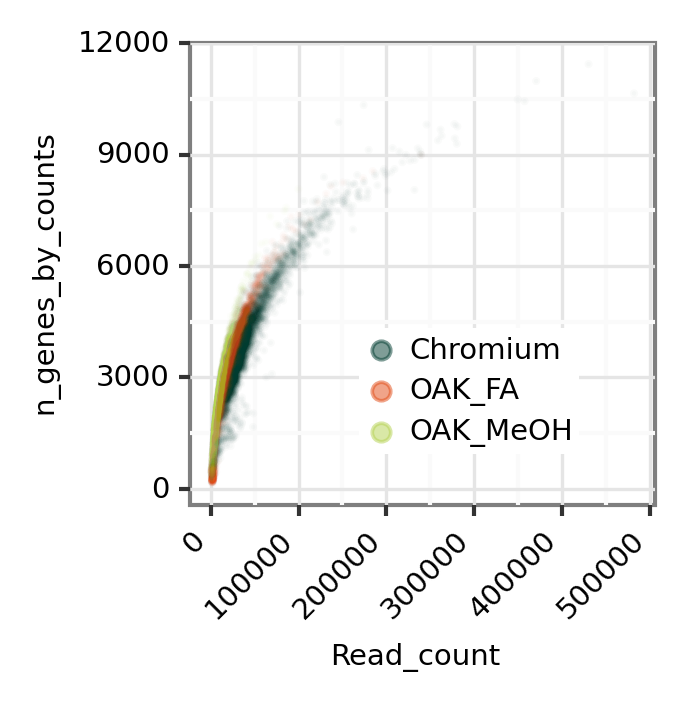

<ggplot: (2932152483033)>

In [44]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='Read_count',y='n_genes_by_counts',color="experiment")
              )
plot+ p9.geom_point(alpha=0.02,size=0.1) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(colour="black",angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(colour="black")) \
+ p9.theme(text=p9.element_text(size=7),legend_position=(0.59,0.3),legend_title=p9.element_blank(),legend_direction='vertical',legend_key=p9.element_blank(),legend_key_size=5,legend_box_margin=0) \
+ p9.guides(color = p9.guide_legend(override_aes={'size' :2,'alpha':0.5 })) \
+ p9.scale_color_manual(values = {'OAK_FA':'#E24B15','Chromium':'#003C30','OAK_MeOH':'#B5D251'}) \
+ p9.theme(figure_size=(2,2)) # 2 inch

In [51]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='Read_count',y='n_genes_by_counts',color="experiment")
              )
plotsave=plot+ p9.geom_point(alpha=0.02,size=0.1) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(colour="black",angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(colour="black")) \
+ p9.theme(text=p9.element_text(size=7),legend_position=(0.59,0.3),legend_title=p9.element_blank(),legend_direction='vertical',legend_key=p9.element_blank(),legend_key_size=5,legend_box_margin=0) \
+ p9.guides(color = p9.guide_legend(override_aes={'size' :2,'alpha':0.5 })) \
+ p9.scale_color_manual(values = {'OAK_FA':'#E24B15','Chromium':'#003C30','OAK_MeOH':'#B5D251'}) \
+ p9.theme(figure_size=(2,2)) # 2 inch
fig=plotsave.draw()
fig.set_size_inches(2, 2)
points = fig.axes[0].collections[0]
points.set_rasterized(True)
fig.savefig('OAK_multiome_RNA_2fixatives.svg',format='svg',dpi=300,bbox_inches='tight')  

In [46]:
df_compare

,barcode,Read_count,n_genes_by_counts,total_counts,experiment
0,AAACATGCAAGCCAGA-1,34909,3648,11090.0,Chromium
1,AAACATGCAAGGACCA-1,21102,2677,6809.0,Chromium
2,AAACATGCAATCCCTT-1,23194,1545,5497.0,Chromium
3,AAACATGCACACAATT-1,39719,3777,12229.0,Chromium
4,AAACATGCATTCCTCG-1,29932,3440,9575.0,Chromium
...,...,...,...,...,...
10534,TTTGTGTTCCGGTTAG-1,6821,2066,3544.0,OAK_MeOH
10535,TTTGTTGGTAGCCTCC-1,8779,2439,4456.0,OAK_MeOH
10536,TTTGTTGGTGAATCGC-1,5221,1676,2577.0,OAK_MeOH
10537,TTTGTTGGTTAGTTGG-1,8268,1841,4003.0,OAK_MeOH


In [45]:
df_compare.to_csv(data_dir+'Fig1j.csv',header=True,index=False)